In [1]:
pip install scikit-bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 94.1 MB/s eta 0:00:00


Depth profile ZOTUs:   5892
Depth profile samples: ['MF.28A', 'MF.31B', 'IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']

Depth samples found: ['IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']

Richness at depth:
   Sample  Depth_cm  Richness
IX.10CM.A        10      1964
IX.20CM.B        20      1897
IX.30CM.A        30      1666
IX.40CM.A        40      1426
IX.50CM.A        50      1685
IX.60CM.A        60      1825
IX.70CM.A        70      1910
IX.80CM.A        80      1966

Spearman rho = 0.238  p = 0.5702  ns


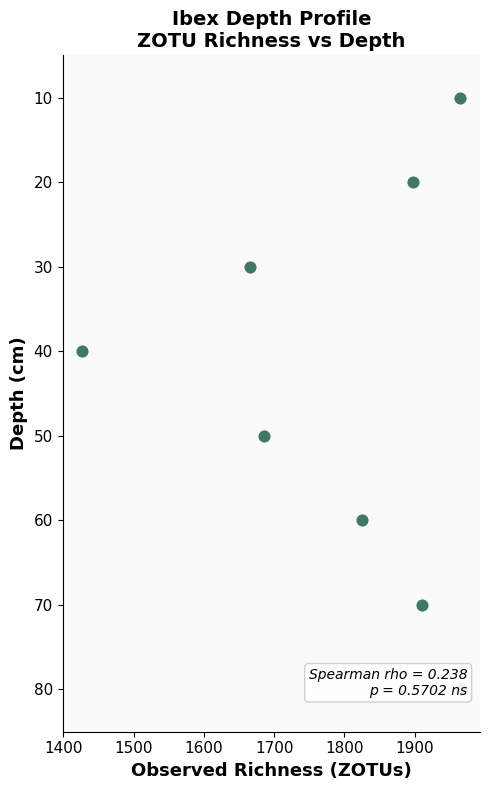

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ============================
# LOAD DEPTH PROFILE FILE
# ============================
depth_count_path = "/content/zotutab_decontam_Final_Depth_Only.csv"

raw_d = pd.read_csv(depth_count_path, header=None)

first_val = str(raw_d.iloc[0, 0]).strip().upper()
if first_val == "ANATOMY":
    header_row_d = 1
    data_start_d = 2
else:
    header_row_d = 0
    data_start_d = 1

df_d = raw_d.iloc[data_start_d:].copy()
df_d.columns = raw_d.iloc[header_row_d].values
df_d.reset_index(drop=True, inplace=True)

tax_cols  = ["Domain", "Phylum", "Class", "Order",
             "Family", "Genus", "Species"]
zotu_col_d = df_d.columns[0]

sample_cols_d = [c for c in df_d.columns
                 if c not in tax_cols
                 and c != zotu_col_d
                 and "Blank" not in str(c)]

df_d[sample_cols_d] = df_d[sample_cols_d].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df_d["Domain"] = df_d["Domain"].str.lower().str.strip()
df_d["Phylum"] = df_d["Phylum"].str.lower().str.strip()

micro_d = df_d[
    df_d["Domain"].isin(["bacteria", "archaea"]) &
    (df_d["Phylum"] != "bacteria") &
    df_d["Phylum"].notna()
].copy()

print(f"Depth profile ZOTUs:   {len(micro_d)}")
print(f"Depth profile samples: {sample_cols_d}")

# ============================
# DEPTH MAP
# ============================
depth_map = {
    "IX.10CM.A":  10,
    "IX.20CM.B":  20,
    "IX.30CM.A":  30,
    "IX.40CM.A":  40,
    "IX.50CM.A":  50,
    "IX.60CM.A":  60,
    "IX.70CM.A":  70,
    "IX.80CM.A":  80,
}

depth_samples = [s for s in sample_cols_d if s in depth_map]
depth_samples.sort(key=lambda s: depth_map[s])
print(f"\nDepth samples found: {depth_samples}")

# ============================
# RICHNESS PER DEPTH SAMPLE
# ============================
def compute_richness(counts):
    counts = counts[counts > 0]
    return len(counts)

records = []
for s in depth_samples:
    counts = micro_d[s].values.astype(float)
    rich   = compute_richness(counts)
    records.append({
        "Sample":   s,
        "Depth_cm": depth_map[s],
        "Richness": rich,
    })

alpha_depth = pd.DataFrame(records)
print(f"\nRichness at depth:")
print(alpha_depth[["Sample", "Depth_cm",
                    "Richness"]].to_string(index=False))

# ============================
# SPEARMAN CORRELATION
# ============================
r, p = spearmanr(alpha_depth["Depth_cm"],
                 alpha_depth["Richness"])
sig  = ("***" if p < 0.001 else "**" if p < 0.01
        else "*" if p < 0.05 else "ns")

print(f"\nSpearman rho = {r:.3f}  p = {p:.4f}  {sig}")

# ============================
# FIGURE
# x = richness, y = depth
# y axis inverted so surface is at top
# no regression line, no depth labels
# ============================
fig, ax = plt.subplots(figsize=(5, 8))
fig.patch.set_facecolor("white")

color = "#2d6a4f"

ax.scatter(alpha_depth["Richness"],
           alpha_depth["Depth_cm"],
           color=color, s=90,
           edgecolors="white", linewidths=0.8,
           alpha=0.9, zorder=3)

# invert y axis so 0 cm is at top
ax.invert_yaxis()

# stats box
ax.text(0.97, 0.05,
        f"Spearman rho = {r:.3f}\n"
        f"p = {p:.4f} {sig}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=10, style="italic",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white",
                  edgecolor="#cccccc",
                  alpha=0.9))

ax.set_xlabel("Observed Richness (ZOTUs)",
              fontsize=13, fontweight="bold")
ax.set_ylabel("Depth (cm)",
              fontsize=13, fontweight="bold")
ax.set_title(
    "Ibex Depth Profile\nZOTU Richness vs Depth",
    fontsize=14, fontweight="bold")

ax.set_ylim(85, 5)
ax.tick_params(labelsize=11)
ax.set_facecolor("#fafafa")
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

plt.tight_layout()

plt.show()


Ibex surface samples (10): ['IX.1B', 'IX.2A', 'IX.3A', 'IX.4B', 'IX.5A', 'IX.6A', 'IX.7A', 'IX.8A', 'IX.9A', 'IX.10A']
Ibex depth samples  (8): ['IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']

Surface slices: 21
Depth slices:   21


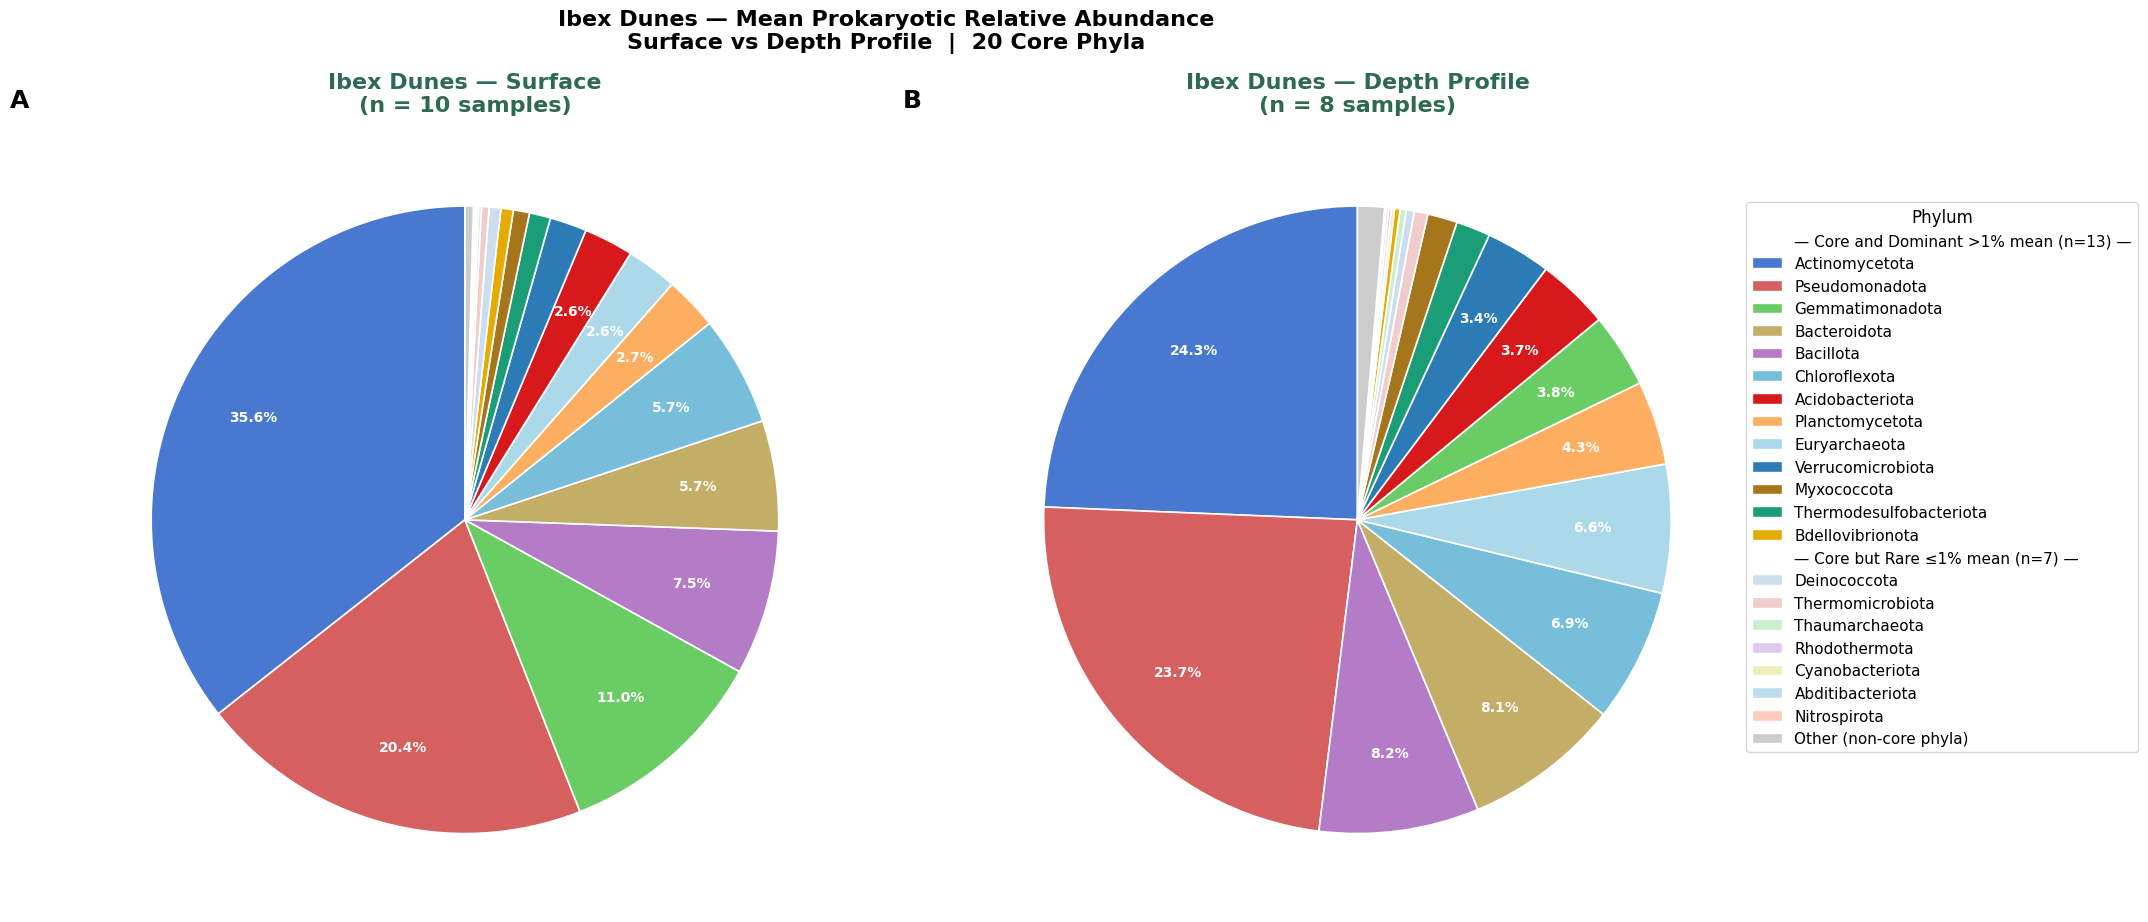

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================
# LOAD RELATIVE ABUNDANCE FILES
# ============================
rel_surf_path  = "/content/zotutab_decontam_RelAbund_Final.csv"
rel_depth_path = "/content/zotutab_decontam_RelAbund_Final_Depth_Only.csv"

def load_relabund(path):
    raw = pd.read_csv(path, header=None)
    first_val = str(raw.iloc[0, 0]).strip().upper()
    if first_val == "ANATOMY":
        header_row = 1
        data_start = 2
    else:
        header_row = 0
        data_start = 1
    df = raw.iloc[data_start:].copy()
    df.columns = raw.iloc[header_row].values
    df.reset_index(drop=True, inplace=True)
    return df

df_surf  = load_relabund(rel_surf_path)
df_depth = load_relabund(rel_depth_path)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]

def get_sample_cols(df):
    zotu_col = df.columns[0]
    return [c for c in df.columns
            if c not in tax_cols
            and c != zotu_col
            and "Blank" not in str(c)]

surf_all_cols  = get_sample_cols(df_surf)
depth_all_cols = get_sample_cols(df_depth)

# ============================
# IBEX SAMPLES
# surface = all IX samples in surface file
# depth   = all IX samples in depth file
# ============================
ibex_surf_cols  = [s for s in surf_all_cols
                   if str(s).startswith("IX")]
ibex_depth_cols = [s for s in depth_all_cols
                   if str(s).startswith("IX")]

print(f"Ibex surface samples ({len(ibex_surf_cols)}): "
      f"{ibex_surf_cols}")
print(f"Ibex depth samples  ({len(ibex_depth_cols)}): "
      f"{ibex_depth_cols}")

# ============================
# FILTER PROKARYOTES
# ============================
def filter_prokaryotes(df, sample_cols):
    df = df.copy()
    df["Domain"] = df["Domain"].str.lower().str.strip()
    df["Phylum"] = df["Phylum"].str.lower().str.strip()
    micro = df[
        df["Domain"].isin(["bacteria", "archaea"]) &
        (df["Phylum"] != "bacteria") &
        df["Phylum"].notna()
    ].copy()
    micro[sample_cols] = micro[sample_cols].apply(
        pd.to_numeric, errors="coerce").fillna(0)
    return micro

micro_surf  = filter_prokaryotes(df_surf,  surf_all_cols)
micro_depth = filter_prokaryotes(df_depth, depth_all_cols)

# ============================
# AGGREGATE TO PHYLUM MEANS
# ============================
def get_phylum_means(micro, sample_cols):
    grouped = micro.groupby("Phylum")[sample_cols].sum()
    means   = grouped[sample_cols].mean(axis=1)
    return means.sort_values(ascending=False)

surf_means  = get_phylum_means(micro_surf,  ibex_surf_cols)
depth_means = get_phylum_means(micro_depth, ibex_depth_cols)

# ============================
# CORE PHYLA LIST
# same 20 phyla as top figure
# ============================
core_phyla_list = [
    "actinomycetota", "pseudomonadota", "gemmatimonadota",
    "bacteroidota", "bacillota", "chloroflexota",
    "acidobacteriota", "planctomycetota", "euryarchaeota",
    "verrucomicrobiota", "myxococcota", "thermodesulfobacteriota",
    "bdellovibrionota", "deinococcota", "thermomicrobiota",
    "thaumarchaeota", "rhodothermota", "cyanobacteriota",
    "abditibacteriota", "nitrospirota"
]

# ============================
# PREPARE PIE DATA
# core phyla shown individually
# everything else collapsed into Other
# ============================
def prep_pie_core(means, core_phyla):
    core_vals = {p: float(means[p])
                 for p in core_phyla
                 if p in means.index}
    other_sum = sum(float(v)
                    for p, v in means.items()
                    if p not in core_phyla)

    core_sorted = dict(sorted(core_vals.items(),
                               key=lambda x: x[1],
                               reverse=True))
    labels = list(core_sorted.keys()) + ["Other"]
    values = list(core_sorted.values()) + [other_sum]
    return labels, values

surf_labels,  surf_vals  = prep_pie_core(
    surf_means,  core_phyla_list)
depth_labels, depth_vals = prep_pie_core(
    depth_means, core_phyla_list)

print(f"\nSurface slices: {len(surf_labels)}")
print(f"Depth slices:   {len(depth_labels)}")

# ============================
# COLOR MAP
# match top figure colors exactly
# same phylum = same color in both pies
# ============================
top_fig_colors = {
    "actinomycetota":          "#4878CF",
    "pseudomonadota":          "#D65F5F",
    "gemmatimonadota":         "#6ACC65",
    "bacillota":               "#B47CC7",
    "bacteroidota":            "#C4AD66",
    "chloroflexota":           "#77BEDB",
    "acidobacteriota":         "#D7191C",
    "planctomycetota":         "#FDAE61",
    "euryarchaeota":           "#ABD9E9",
    "verrucomicrobiota":       "#2C7BB6",
    "myxococcota":             "#A6761D",
    "bdellovibrionota":        "#E6AB02",
    "thermodesulfobacteriota": "#1B9E77",
    "deinococcota":            "#CCDDEE",
    "thermomicrobiota":        "#F0CCCC",
    "thaumarchaeota":          "#CCEECC",
    "rhodothermota":           "#DDCCEE",
    "cyanobacteriota":         "#EEEEBB",
    "abditibacteriota":        "#BBDDEE",
    "nitrospirota":            "#FFCCBB",
    "Other":                   "#CCCCCC",
}

# ============================
# FIGURE — two pie charts
# ============================
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor("white")

def draw_pie(ax, labels, values, title,
             n_samples, panel_label):

    colors = [top_fig_colors.get(l, "#CCCCCC")
              for l in labels]

    def autopct_fmt(pct):
        return f"{pct:.1f}%" if pct >= 2.0 else ""

    wedges, texts, autotexts = ax.pie(
        values,
        colors=colors,
        autopct=autopct_fmt,
        pctdistance=0.75,
        startangle=90,
        wedgeprops=dict(edgecolor="white",
                        linewidth=1.2),
    )
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_fontweight("bold")
        autotext.set_color("white")

    ax.set_title(
        f"{title}\n(n = {n_samples} samples)",
        fontsize=16, fontweight="bold",
        color="#2d6a4f", pad=12)

    ax.text(-0.08, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=18, fontweight="bold",
            va="top", ha="left")

draw_pie(axes[0],
         surf_labels, surf_vals,
         "Ibex Dunes — Surface",
         len(ibex_surf_cols), "A")

draw_pie(axes[1],
         depth_labels, depth_vals,
         "Ibex Dunes — Depth Profile",
         len(ibex_depth_cols), "B")

# ============================
# LEGEND
# dominant core phyla first then rare core then other
# ============================
dominant_core = [
    "actinomycetota", "pseudomonadota", "gemmatimonadota",
    "bacteroidota", "bacillota", "chloroflexota",
    "acidobacteriota", "planctomycetota", "euryarchaeota",
    "verrucomicrobiota", "myxococcota", "thermodesulfobacteriota",
    "bdellovibrionota"
]
rare_core = [
    "deinococcota", "thermomicrobiota", "thaumarchaeota",
    "rhodothermota", "cyanobacteriota", "abditibacteriota",
    "nitrospirota"
]

legend_handles = []

legend_handles.append(
    Patch(facecolor="none", edgecolor="none",
          label="— Core and Dominant >1% mean (n=13) —"))
for p in dominant_core:
    legend_handles.append(
        Patch(facecolor=top_fig_colors[p],
              edgecolor="white",
              label=p.capitalize()))

legend_handles.append(
    Patch(facecolor="none", edgecolor="none",
          label="— Core but Rare ≤1% mean (n=7) —"))
for p in rare_core:
    legend_handles.append(
        Patch(facecolor=top_fig_colors[p],
              edgecolor="white",
              label=p.capitalize()))

legend_handles.append(
    Patch(facecolor="#CCCCCC", edgecolor="white",
          label="Other (non-core phyla)"))

fig.legend(
    handles=legend_handles,
    loc="center right",
    bbox_to_anchor=(1.20, 0.5),
    fontsize=11, frameon=True,
    edgecolor="#cccccc",
    title="Phylum",
    title_fontsize=12,
)

fig.suptitle(
    "Ibex Dunes — Mean Prokaryotic Relative Abundance\n"
    "Surface vs Depth Profile  |  20 Core Phyla",
    fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()

plt.show()


Depth samples: ['IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']
Depth OTU matrix: (8, 5892)

Mantel test — BC vs depth difference:
  r = 0.822  p = 0.0010  **

Spearman — BC from surface vs depth:
  rho = 0.964  p = 0.0005  ***


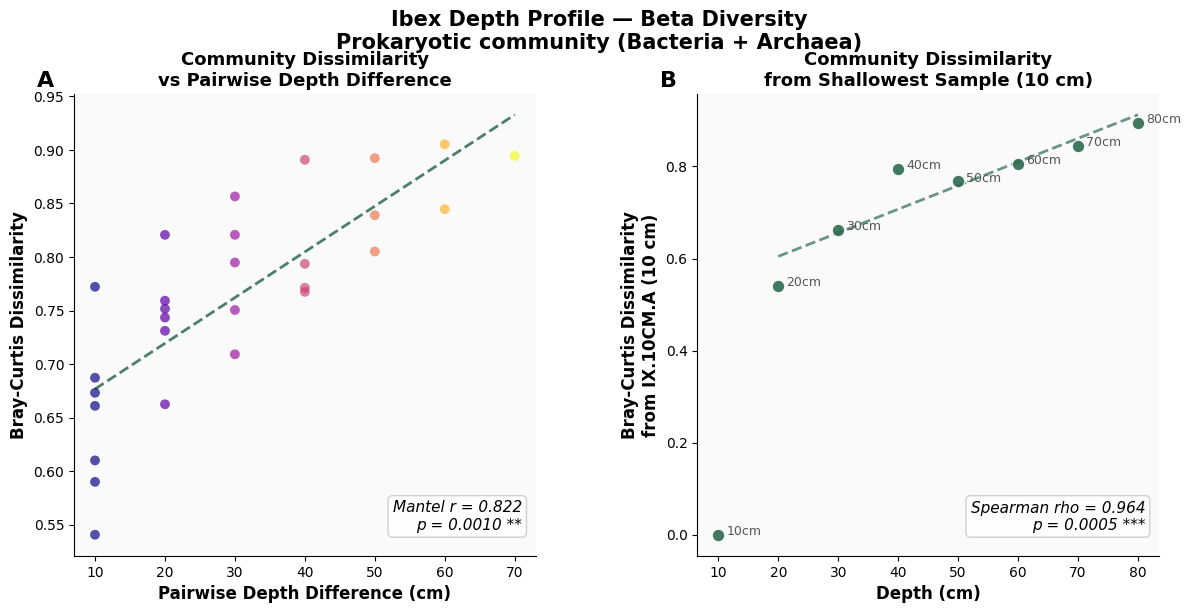

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, linregress
from skbio.stats.distance import mantel, DistanceMatrix

# ============================
# PATHS
# ============================
depth_rel_path = "/content/zotutab_decontam_RelAbund_Final_Depth_Only.csv"

# ============================
# DEPTH MAP
# ============================
depth_map = {
    "IX.10CM.A":  10,
    "IX.20CM.B":  20,
    "IX.30CM.A":  30,
    "IX.40CM.A":  40,
    "IX.50CM.A":  50,
    "IX.60CM.A":  60,
    "IX.70CM.A":  70,
    "IX.80CM.A":  80,
}

# ============================
# TAXONOMY COLUMNS
# ============================
tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]

# ============================
# IBEX COLOR
# ============================
color = "#2d6a4f"

# ============================
# LOAD RELABUND DEPTH FILE
# ============================
raw_r     = pd.read_csv(depth_rel_path, header=None)
first_val = str(raw_r.iloc[0, 0]).strip().upper()

if first_val == "ANATOMY":
    header_row_r = 1
    data_start_r = 2
else:
    header_row_r = 0
    data_start_r = 1

df_r = raw_r.iloc[data_start_r:].copy()
df_r.columns = raw_r.iloc[header_row_r].values
df_r.reset_index(drop=True, inplace=True)

zotu_col_r    = df_r.columns[0]
sample_cols_r = [c for c in df_r.columns
                 if c not in tax_cols
                 and c != zotu_col_r
                 and "Blank" not in str(c)]

df_r[sample_cols_r] = df_r[sample_cols_r].apply(
    pd.to_numeric, errors="coerce").fillna(0)

df_r["Domain"] = df_r["Domain"].str.lower().str.strip()
df_r["Phylum"] = df_r["Phylum"].str.lower().str.strip()

micro_r = df_r[
    df_r["Domain"].isin(["bacteria", "archaea"]) &
    (df_r["Phylum"] != "bacteria") &
    df_r["Phylum"].notna()
].copy()

# ============================
# DEPTH SAMPLES — sorted by depth
# ============================
depth_samps_r = [s for s in sample_cols_r
                 if s in depth_map]
depth_samps_r.sort(key=lambda s: depth_map[s])

print(f"Depth samples: {depth_samps_r}")

# ============================
# BUILD OTU MATRIX
# ============================
otu_depth = (
    micro_r.set_index(zotu_col_r)[depth_samps_r]
    .T.fillna(0)
)
otu_depth.index.name   = None
otu_depth.columns.name = None

print(f"Depth OTU matrix: {otu_depth.shape}")

# ============================
# BRAY-CURTIS DISTANCE MATRIX
# ============================
bc_mat = squareform(pdist(
    otu_depth.values.astype(float),
    metric="braycurtis"))

n          = len(depth_samps_r)
idx        = np.triu_indices(n, k=1)
depths_arr = np.array([depth_map[s]
                        for s in depth_samps_r])
depth_diff = np.abs(
    depths_arr[:, None] - depths_arr[None, :])

x_pairs = depth_diff[idx]
y_pairs = bc_mat[idx]

# ============================
# MANTEL TEST
# pairwise BC vs pairwise depth difference
# ============================
ids = list(range(n))
r_m, p_m, _ = mantel(
    DistanceMatrix(depth_diff, ids=ids),
    DistanceMatrix(bc_mat,     ids=ids),
    method="spearman", permutations=999)

sig_m = ("***" if p_m < 0.001 else
         "**"  if p_m < 0.01  else
         "*"   if p_m < 0.05  else "ns")

print(f"\nMantel test — BC vs depth difference:")
print(f"  r = {r_m:.3f}  p = {p_m:.4f}  {sig_m}")

# ============================
# SPEARMAN — BC from shallowest
# sample vs increasing depth
# ============================
bc_from_surface = bc_mat[0, :]
depths_vals     = [depth_map[s] for s in depth_samps_r]

r_sp, p_sp = spearmanr(depths_vals[1:],
                        bc_from_surface[1:])
sig_sp = ("***" if p_sp < 0.001 else
          "**"  if p_sp < 0.01  else
          "*"   if p_sp < 0.05  else "ns")

print(f"\nSpearman — BC from surface vs depth:")
print(f"  rho = {r_sp:.3f}  p = {p_sp:.4f}  {sig_sp}")

# ============================
# FIGURE
# Panel A — pairwise BC vs depth difference
# Panel B — BC from shallowest vs depth
# ============================
fig, axes = plt.subplots(
    1, 2, figsize=(14, 6),
    gridspec_kw={"wspace": 0.35})
fig.patch.set_facecolor("white")

# ============================
# PANEL A — Mantel scatter
# ============================
ax = axes[0]
ax.scatter(x_pairs, y_pairs,
           c=x_pairs, cmap="plasma",
           alpha=0.7, s=50, linewidths=0,
           vmin=x_pairs.min(), vmax=x_pairs.max(),
           zorder=3)

slope, intercept, _, _, _ = linregress(x_pairs, y_pairs)
x_ln = np.linspace(x_pairs.min(), x_pairs.max(), 200)
ax.plot(x_ln, slope * x_ln + intercept,
        color=color, linewidth=2,
        linestyle="--", alpha=0.85)

ax.text(0.97, 0.05,
        f"Mantel r = {r_m:.3f}\n"
        f"p = {p_m:.4f} {sig_m}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=11, style="italic",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white",
                  edgecolor="#cccccc",
                  alpha=0.9))

ax.text(-0.08, 1.05, "A",
        transform=ax.transAxes,
        fontsize=16, fontweight="bold", va="top")
ax.set_xlabel("Pairwise Depth Difference (cm)",
              fontsize=12, fontweight="bold")
ax.set_ylabel("Bray-Curtis Dissimilarity",
              fontsize=12, fontweight="bold")
ax.set_title(
    "Community Dissimilarity\nvs Pairwise Depth Difference",
    fontsize=13, fontweight="bold")
ax.set_facecolor("#fafafa")
for sp_ in ["top", "right"]:
    ax.spines[sp_].set_visible(False)

# ============================
# PANEL B — BC from surface vs depth
# ============================
ax2 = axes[1]
sfc = depth_samps_r[0]

ax2.scatter(depths_vals, bc_from_surface,
            color=color, s=80,
            edgecolors="white", linewidths=0.8,
            alpha=0.9, zorder=3)

for s, d, b in zip(depth_samps_r,
                    depths_vals,
                    bc_from_surface):
    ax2.annotate(f"{d}cm", (d, b),
                 textcoords="offset points",
                 xytext=(6, 0), fontsize=9,
                 color="#555555")

slope2, intercept2, _, _, _ = linregress(
    depths_vals[1:], bc_from_surface[1:])
x_ln2 = np.linspace(depths_vals[1],
                     depths_vals[-1], 200)
ax2.plot(x_ln2, slope2 * x_ln2 + intercept2,
         color=color, linewidth=2,
         linestyle="--", alpha=0.7)

ax2.text(0.97, 0.05,
         f"Spearman rho = {r_sp:.3f}\n"
         f"p = {p_sp:.4f} {sig_sp}",
         transform=ax2.transAxes,
         ha="right", va="bottom",
         fontsize=11, style="italic",
         bbox=dict(boxstyle="round,pad=0.3",
                   facecolor="white",
                   edgecolor="#cccccc",
                   alpha=0.9))

ax2.text(-0.08, 1.05, "B",
         transform=ax2.transAxes,
         fontsize=16, fontweight="bold", va="top")
ax2.set_xlabel("Depth (cm)",
               fontsize=12, fontweight="bold")
ax2.set_ylabel(
    f"Bray-Curtis Dissimilarity\nfrom {sfc} (10 cm)",
    fontsize=12, fontweight="bold")
ax2.set_title(
    "Community Dissimilarity\nfrom Shallowest Sample (10 cm)",
    fontsize=13, fontweight="bold")
ax2.set_facecolor("#fafafa")
for sp_ in ["top", "right"]:
    ax2.spines[sp_].set_visible(False)

fig.suptitle(
    "Ibex Depth Profile — Beta Diversity\n"
    "Prokaryotic community (Bacteria + Archaea)",
    fontsize=15, fontweight="bold", y=1.02)

plt.show()


Prokaryotic ZOTUs: 5892  |  Samples: 52
Surface samples: 52
Depth samples: ['IX.10CM.A', 'IX.20CM.B', 'IX.30CM.A', 'IX.40CM.A', 'IX.50CM.A', 'IX.60CM.A', 'IX.70CM.A', 'IX.80CM.A']
Depth OTU matrix: (8, 5892)
Combined matrix: (60, 5892)

PCoA variance: PCo1=15.2%  PCo2=11.0%

PERMANOVA surface vs depth:
  p = 0.0010  **
Saved: pcoa_surface_plus_depth.png


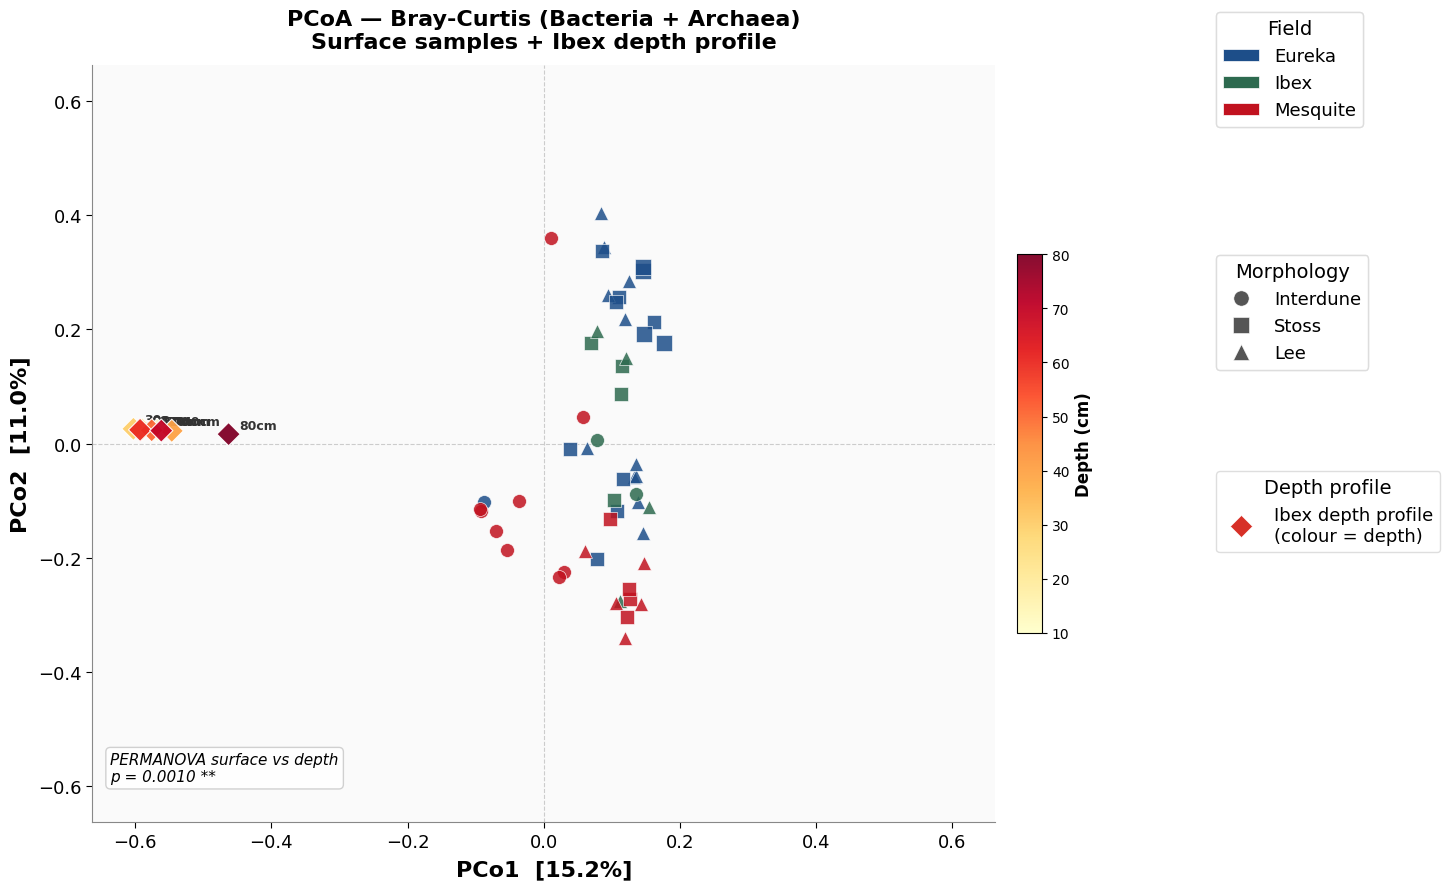

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.distance import permanova, permdisp
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# ============================
# LOAD SURFACE OTU
# ============================
def load_otu(path):
    raw = pd.read_csv(path, header=None)
    first_val = str(raw.iloc[0, 0]).strip().upper()
    if first_val == "ANATOMY":
        header_row = 1
        data_start = 2
    else:
        header_row = 0
        data_start = 1

    df = raw.iloc[data_start:].copy()
    df.columns = raw.iloc[header_row].values
    df.reset_index(drop=True, inplace=True)

    n_tax     = 7
    tax_cols  = list(df.columns[-n_tax:])
    samp_cols = [c for c in df.columns[1:]
                 if c not in tax_cols
                 and "Blank" not in str(c)]

    for col in samp_cols:
        df[col] = pd.to_numeric(df[col],
                                errors="coerce").fillna(0)

    domain_col = tax_cols[0]
    df[domain_col] = (df[domain_col].astype(str)
                      .str.strip().str.lower())
    micro = df[df[domain_col].isin(
        ["bacteria", "archaea"])].copy()

    print(f"Prokaryotic ZOTUs: {len(micro)}  "
          f"|  Samples: {len(samp_cols)}")

    return pd.DataFrame(
        micro[samp_cols].values.T,
        index=samp_cols,
        columns=micro[micro.columns[0]]
    )

otu_surf = load_otu("/content/zotutab_decontam_Final.csv")

meta = pd.read_csv("/content/PERM_metadata.csv").rename(
           columns={"Sample Name:": "SampleID"})
meta["SampleID"] = meta["SampleID"].str.strip()
meta = meta.set_index("SampleID")

shared   = sorted(set(otu_surf.index) & set(meta.index))
otu_surf = otu_surf.loc[shared]
meta_aln = meta.loc[shared].copy()
meta_aln["Morphology"] = meta_aln["Morphology"].str.strip()

print(f"Surface samples: {len(shared)}")

# ============================
# LOAD DEPTH OTU
# uses relabund depth file
# ============================
rel_depth_path = "/content/zotutab_decontam_RelAbund_Final_Depth_Only.csv"
raw_dep = pd.read_csv(rel_depth_path, header=None)

first_val_d = str(raw_dep.iloc[0, 0]).strip().upper()
if first_val_d == "ANATOMY":
    header_row_d = 1
    data_start_d = 2
else:
    header_row_d = 0
    data_start_d = 1

df_dep = raw_dep.iloc[data_start_d:].copy()
df_dep.columns = raw_dep.iloc[header_row_d].values
df_dep.reset_index(drop=True, inplace=True)

tax_cols = ["Domain", "Phylum", "Class", "Order",
            "Family", "Genus", "Species"]
zotu_col_d = df_dep.columns[0]

sample_cols_d = [c for c in df_dep.columns
                 if c not in tax_cols
                 and c != zotu_col_d
                 and "Blank" not in str(c)]

df_dep[sample_cols_d] = df_dep[sample_cols_d].apply(
    pd.to_numeric, errors="coerce").fillna(0)
df_dep["Domain"] = df_dep["Domain"].str.lower().str.strip()
df_dep["Phylum"] = df_dep["Phylum"].str.lower().str.strip()

micro_dep = df_dep[
    df_dep["Domain"].isin(["bacteria", "archaea"]) &
    (df_dep["Phylum"] != "bacteria") &
    df_dep["Phylum"].notna()
].copy()

depth_map = {
    "IX.10CM.A": 10, "IX.20CM.B": 20,
    "IX.30CM.A": 30, "IX.40CM.A": 40,
    "IX.50CM.A": 50, "IX.60CM.A": 60,
    "IX.70CM.A": 70, "IX.80CM.A": 80,
}

depth_samps = [s for s in sample_cols_d if s in depth_map]
depth_samps.sort(key=lambda s: depth_map[s])

otu_depth = (
    micro_dep.set_index(zotu_col_d)[depth_samps]
    .T.fillna(0)
)
otu_depth.index.name   = None
otu_depth.columns.name = None

print(f"Depth samples: {depth_samps}")
print(f"Depth OTU matrix: {otu_depth.shape}")

# ============================
# COMBINE SURFACE + DEPTH
# align columns (ZOTUs)
# ============================
all_cols      = otu_surf.columns.union(otu_depth.columns)
otu_surf_aln  = otu_surf.reindex(
    columns=all_cols, fill_value=0)
otu_depth_aln = otu_depth.reindex(
    columns=all_cols, fill_value=0)

otu_combined = pd.concat([otu_surf_aln, otu_depth_aln])
print(f"Combined matrix: {otu_combined.shape}")

# ============================
# BRAY-CURTIS ON COMBINED
# ============================
bc_comb = squareform(pdist(
    otu_combined.values.astype(float),
    metric="braycurtis"))

# ============================
# PCoA
# ============================
D2   = bc_comb ** 2
B    = -0.5 * (D2
               - D2.mean(1, keepdims=True)
               - D2.mean(0, keepdims=True)
               + D2.mean())
ev, evec = np.linalg.eigh(B)
idx  = np.argsort(ev)[::-1]
ev   = ev[idx]
evec = evec[:, idx]
pos  = ev > 0
coords_comb = evec[:, pos] * np.sqrt(ev[pos])
var_comb    = ev[pos] / ev[pos].sum() * 100

print(f"\nPCoA variance: PCo1={var_comb[0]:.1f}%  "
      f"PCo2={var_comb[1]:.1f}%")

# ============================
# PERMANOVA — surface vs depth
# ============================
n_surf  = len(shared)
n_depth = len(depth_samps)

group_labels = ["surface"] * n_surf + ["depth"] * n_depth
group_series = pd.Series(
    group_labels,
    index=list(otu_combined.index),
    name="Group")

dm_comb  = DistanceMatrix(bc_comb,
                           ids=list(otu_combined.index))
res_perm = permanova(dm_comb, group_series,
                     permutations=999)
p_perm   = res_perm["p-value"]
sig_perm = ("***" if p_perm < 0.001 else
            "**"  if p_perm < 0.01  else
            "*"   if p_perm < 0.05  else "ns")

print(f"\nPERMANOVA surface vs depth:")
print(f"  p = {p_perm:.4f}  {sig_perm}")

# ============================
# HELPER FUNCTIONS
# ============================
def get_field(s):
    if str(s).startswith("MF"): return "Mesquite"
    if str(s).startswith("ED"): return "Eureka"
    if str(s).startswith("IX") and "CM" not in str(s):
        return "Ibex"
    return "Other"

FIELD_COLORS = {
    "Eureka":   "#1d4e89",
    "Ibex":     "#2d6a4f",
    "Mesquite": "#c1121f"
}

MORPH_STYLE = {
    "Interdune":        ("o", 100),
    "Stoss":            ("s",  95),
    "Lee":              ("^", 100),
    "Stoss, Depth":     ("s",  95),
    "Stoss , Depth":    ("s",  95),
    "Interdune, Depth": ("o",  95),
    "Stoss, Star":      ("s", 140),
    "Stoss , Star":     ("s", 140),
    "Lee, Star":        ("^", 100),
    "Stoss, Crest":     ("s",  95),
}

# ============================
# FIGURE
# ============================
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor("white")

# ============================
# PLOT SURFACE SAMPLES
# coloured by field, shaped by morphology
# ============================
fields = [get_field(s) for s in shared]
morphs = meta_aln["Morphology"].fillna(
    "Interdune").str.strip().tolist()

for i in range(n_surf):
    fc     = FIELD_COLORS.get(fields[i], "gray")
    mk, sz = MORPH_STYLE.get(morphs[i], ("o", 100))
    ax.scatter(coords_comb[i, 0], coords_comb[i, 1],
               color=fc, marker=mk, s=sz,
               edgecolors="white", linewidths=0.5,
               alpha=0.85, zorder=3)

# ============================
# PLOT DEPTH SAMPLES
# coloured by depth using colormap
# diamond marker
# ============================
depth_vals_plot = [depth_map[s] for s in depth_samps]

sc = ax.scatter(
    coords_comb[n_surf:, 0],
    coords_comb[n_surf:, 1],
    c=depth_vals_plot,
    cmap="YlOrRd",
    marker="D", s=140,
    edgecolors="white", linewidths=0.8,
    alpha=0.95, zorder=5,
    vmin=10, vmax=80)

# label depth points
for i, (x_c, y_c, d) in enumerate(zip(
        coords_comb[n_surf:, 0],
        coords_comb[n_surf:, 1],
        depth_vals_plot)):
    ax.annotate(f"{d}cm", (x_c, y_c),
                textcoords="offset points",
                xytext=(8, 4), fontsize=9,
                color="#333333", fontweight="bold")

# colorbar for depth
cbar = fig.colorbar(sc, ax=ax, shrink=0.5,
                     pad=0.02, aspect=15)
cbar.set_label("Depth (cm)", fontsize=12,
               fontweight="bold")
cbar.ax.tick_params(labelsize=10)

# ============================
# AXES
# ============================
h = max(abs(coords_comb[:, 0]).max(),
        abs(coords_comb[:, 1]).max()) * 1.10

ax.axhline(0, color="#cccccc", lw=0.8, ls="--", zorder=1)
ax.axvline(0, color="#cccccc", lw=0.8, ls="--", zorder=1)
ax.set_xlim(-h, h)
ax.set_ylim(-h, h)
ax.set_xlabel(f"PCo1  [{var_comb[0]:.1f}%]",
              fontsize=16, fontweight="bold", labelpad=6)
ax.set_ylabel(f"PCo2  [{var_comb[1]:.1f}%]",
              fontsize=16, fontweight="bold", labelpad=6)
ax.set_title(
    "PCoA — Bray-Curtis (Bacteria + Archaea)\n"
    "Surface samples + Ibex depth profile",
    fontsize=16, fontweight="bold", pad=12)
ax.tick_params(labelsize=13, length=4, width=0.8)
ax.set_facecolor("#fafafa")
for sp_ in ["top", "right"]:
    ax.spines[sp_].set_visible(False)
for sp_ in ["bottom", "left"]:
    ax.spines[sp_].set_color("#888888")

# ============================
# PERMANOVA annotation
# ============================
ax.text(0.02, 0.05,
        f"PERMANOVA surface vs depth\n"
        f"p = {p_perm:.4f} {sig_perm}",
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=11, style="italic",
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="white",
                  edgecolor="#cccccc",
                  alpha=0.9))

# ============================
# LEGENDS
# field colours + morphology symbols
# + depth profile indicator
# ============================
field_handles = [
    mpatches.Patch(facecolor=c, edgecolor="white",
                   lw=0.5, label=f)
    for f, c in FIELD_COLORS.items()
]

morph_legend_items = [
    ("Interdune", "o", 11),
    ("Stoss",     "s", 11),
    ("Lee",       "^", 11),
]
morph_handles = [
    plt.Line2D([0],[0], marker=mk, color="w",
               markerfacecolor="#555555",
               markeredgecolor="white",
               markeredgewidth=0.4,
               markersize=ms, label=mo, linewidth=0)
    for mo, mk, ms in morph_legend_items
]

depth_handle = plt.Line2D(
    [0],[0], marker="D", color="w",
    markerfacecolor="#D73027",
    markeredgecolor="white",
    markeredgewidth=0.4,
    markersize=11,
    label="Ibex depth profile\n(colour = depth)",
    linewidth=0)

leg1 = fig.legend(
    handles=field_handles,
    title="Field",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.99),
    frameon=True, framealpha=0.95,
    edgecolor="#dddddd",
    fontsize=13, title_fontsize=14)

leg2 = fig.legend(
    handles=morph_handles,
    title="Morphology",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.72),
    frameon=True, framealpha=0.95,
    edgecolor="#dddddd",
    fontsize=13, title_fontsize=14)

leg3 = fig.legend(
    handles=[depth_handle],
    title="Depth profile",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.48),
    frameon=True, framealpha=0.95,
    edgecolor="#dddddd",
    fontsize=13, title_fontsize=14)

fig.add_artist(leg1)
fig.add_artist(leg2)

plt.tight_layout()

print("Saved: pcoa_surface_plus_depth.png")


Building PCoA of surface + depth samples...
Combined matrix: (18, 5892)

PERMANOVA surface vs depth:
  p = 0.0010  **


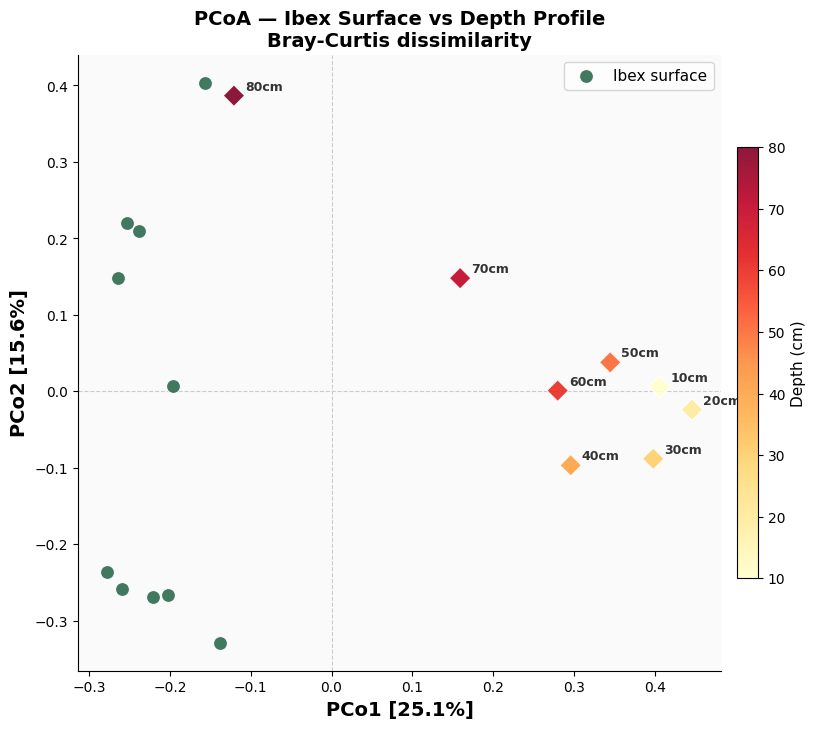

In [4]:
# ============================
# FIGURE 3 — PCoA
# surface + depth together
# coloured by depth
# ============================
print("\nBuilding PCoA of surface + depth samples...")

# load surface relabund
rel_surf_path = "/content/zotutab_decontam_RelAbund_Final.csv"
raw_s = pd.read_csv(rel_surf_path, header=None)
df_s  = raw_s.iloc[2:].copy()
df_s.columns = raw_s.iloc[1]
df_s.reset_index(drop=True, inplace=True)

surf_sample_cols = [c for c in df_s.columns
                    if c not in tax_cols
                    and c != df_s.columns[0]
                    and "Blank" not in str(c)]

df_s[surf_sample_cols] = df_s[surf_sample_cols].apply(
    pd.to_numeric, errors="coerce").fillna(0)
df_s["Domain"] = df_s["Domain"].str.lower().str.strip()
df_s["Phylum"] = df_s["Phylum"].str.lower().str.strip()

micro_s = df_s[
    df_s["Domain"].isin(["bacteria", "archaea"]) &
    (df_s["Phylum"] != "bacteria") &
    df_s["Phylum"].notna()
].copy()

# Ibex surface samples only
ibex_surf = [s for s in surf_sample_cols
             if s.startswith("IX")
             and "CM" not in s]

zotu_col_s = micro_s.columns[0]
otu_surf_ibex = (
    micro_s.set_index(zotu_col_s)[ibex_surf]
    .T.fillna(0)
)

# align columns between surface and depth
all_cols = otu_surf_ibex.columns.union(
    otu_depth.columns)
otu_surf_aln  = otu_surf_ibex.reindex(
    columns=all_cols, fill_value=0)
otu_depth_aln = otu_depth.reindex(
    columns=all_cols, fill_value=0)

otu_combined = pd.concat(
    [otu_surf_aln, otu_depth_aln])

print(f"Combined matrix: {otu_combined.shape}")

# PCoA
bc_comb = squareform(pdist(
    otu_combined.values.astype(float),
    metric="braycurtis"))

D2   = bc_comb ** 2
B    = -0.5 * (D2
               - D2.mean(1, keepdims=True)
               - D2.mean(0, keepdims=True)
               + D2.mean())
ev, evec = np.linalg.eigh(B)
idx  = np.argsort(ev)[::-1]
ev   = ev[idx]; evec = evec[:, idx]
pos  = ev > 0
coords = evec[:, pos] * np.sqrt(ev[pos])
var    = ev[pos] / ev[pos].sum() * 100

fig3, ax3 = plt.subplots(figsize=(10, 8))
fig3.patch.set_facecolor("white")

n_surf  = len(ibex_surf)
n_depth = len(depth_samps_r)

# surface Ibex samples
ax3.scatter(coords[:n_surf, 0], coords[:n_surf, 1],
            c="#2d6a4f", marker="o", s=100,
            edgecolors="white", linewidths=0.8,
            alpha=0.9, zorder=3,
            label="Ibex surface")

# depth samples coloured by depth
depth_vals_plot = [depth_map[s] for s in depth_samps_r]
sc = ax3.scatter(
    coords[n_surf:, 0], coords[n_surf:, 1],
    c=depth_vals_plot, cmap="YlOrRd",
    marker="D", s=120,
    edgecolors="white", linewidths=0.8,
    alpha=0.9, zorder=4,
    vmin=10, vmax=80)

# label depth points
for i, (x_c, y_c, d) in enumerate(zip(
        coords[n_surf:, 0],
        coords[n_surf:, 1],
        depth_vals_plot)):
    ax3.annotate(f"{d}cm", (x_c, y_c),
                 textcoords="offset points",
                 xytext=(8, 4), fontsize=9,
                 color="#333333", fontweight="bold")

cbar = fig3.colorbar(sc, ax=ax3, shrink=0.7,
                     pad=0.02)
cbar.set_label("Depth (cm)", fontsize=11)

ax3.axhline(0, color="#cccccc", lw=0.8,
            ls="--", zorder=1)
ax3.axvline(0, color="#cccccc", lw=0.8,
            ls="--", zorder=1)

ax3.set_xlabel(f"PCo1 [{var[0]:.1f}%]",
               fontsize=14, fontweight="bold")
ax3.set_ylabel(f"PCo2 [{var[1]:.1f}%]",
               fontsize=14, fontweight="bold")
ax3.set_title(
    "PCoA — Ibex Surface vs Depth Profile\n"
    "Bray-Curtis dissimilarity",
    fontsize=14, fontweight="bold")
ax3.legend(fontsize=11, frameon=True,
           edgecolor="#cccccc")
ax3.set_facecolor("#fafafa")
for sp_ in ["top", "right"]:
    ax3.spines[sp_].set_visible(False)

# PERMANOVA surface vs depth
group_labels = (["surface"] * n_surf +
                ["depth"]   * n_depth)
group_series = pd.Series(
    group_labels,
    index=list(otu_combined.index),
    name="Group")

dm_comb = DistanceMatrix(bc_comb,
                          ids=list(otu_combined.index))
res_perm = permanova(dm_comb, group_series,
                     permutations=999)
p_perm   = res_perm["p-value"]
sig_perm = ("***" if p_perm < 0.001 else
            "**"  if p_perm < 0.01  else
            "*"   if p_perm < 0.05  else "ns")

print(f"\nPERMANOVA surface vs depth:")
print(f"  p = {p_perm:.4f}  {sig_perm}")

# ax3.text(0.02, 0.05,
#          f"PERMANOVA surface vs depth\n"
#          f"p = {p_perm:.4f} {sig_perm}",
#          transform=ax3.transAxes,
#          ha="right", va="bottom",
#          fontsize=10, style="italic",
#          bbox=dict(boxstyle="round,pad=0.3",
#                    facecolor="white",
#                    edgecolor="#cccccc",
#                    alpha=0.9))

plt.show()